In [3]:

import importlib
import sftools
import sftools.postprocess as pp
import sftools.plotting    as pl
import sftools.validation  as val
importlib.reload(sftools.validation)
importlib.reload(sftools.plotting)
import sftools.validation  as val
import sftools.plotting as pl



## Open data

In [4]:
#H = "hindcast/model-runs/Canary_12/20251225/hcast/CROCO_FILES/croco_his.nc"
H = "/home/yvan/seaforward/hindcast/model-runs/Canary_12/20251225/hcast/CROCO_FILES/croco_his.nc"
ds = pp.open_history(H, Yorig=1993)

#### Parameters

In [5]:
depth = 1000
lon0, lat0, lon1, lat1 = -21, -16, 21, 21
isobaths = [100, 200, 500, 1000, 2000]


## Horizontal section

### Salinity

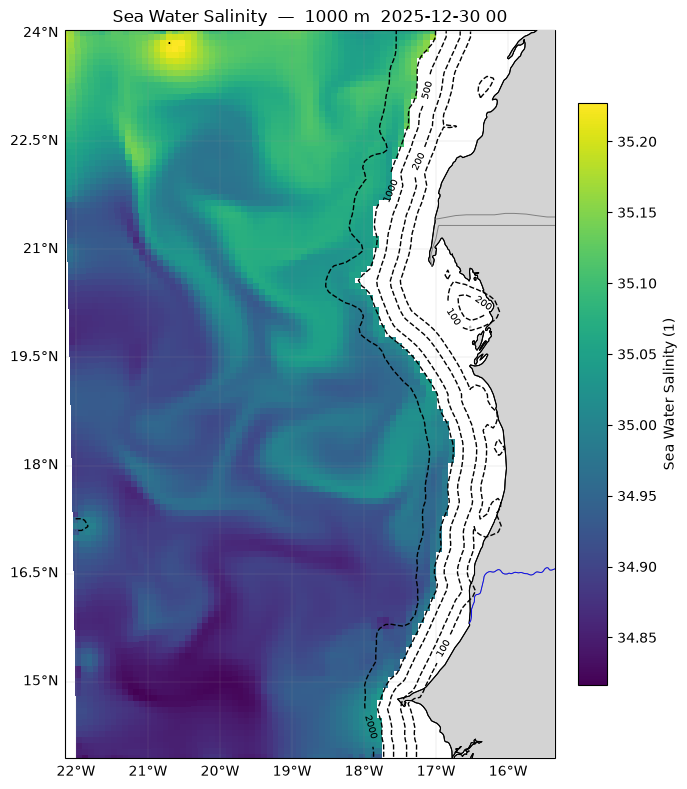

In [6]:
%matplotlib inline

fig = pl.plot(pp.field(ds, "salt", depth_m=depth),ds=ds, isobaths=isobaths)   # no out= -> returns the figure


### Temperature

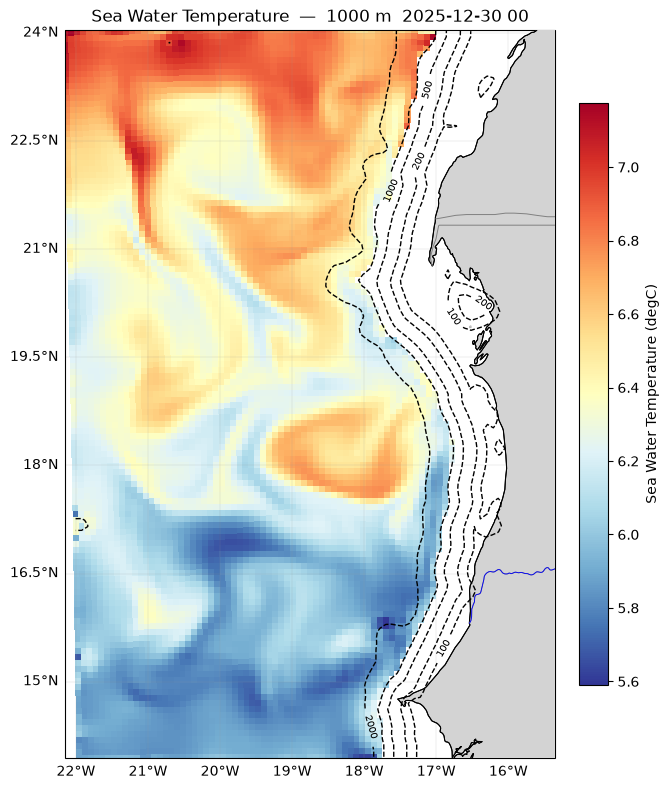

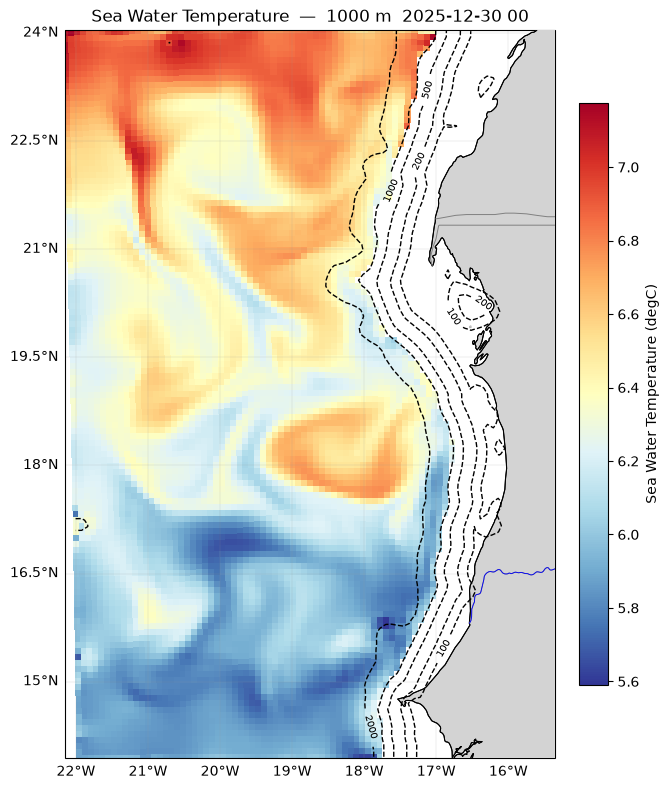

In [ ]:
fig = pl.plot(pp.field(ds, "temp", depth_m=depth),ds=ds, isobaths=isobaths)   # no out= -> returns the figure

### Curent & Speed at depth

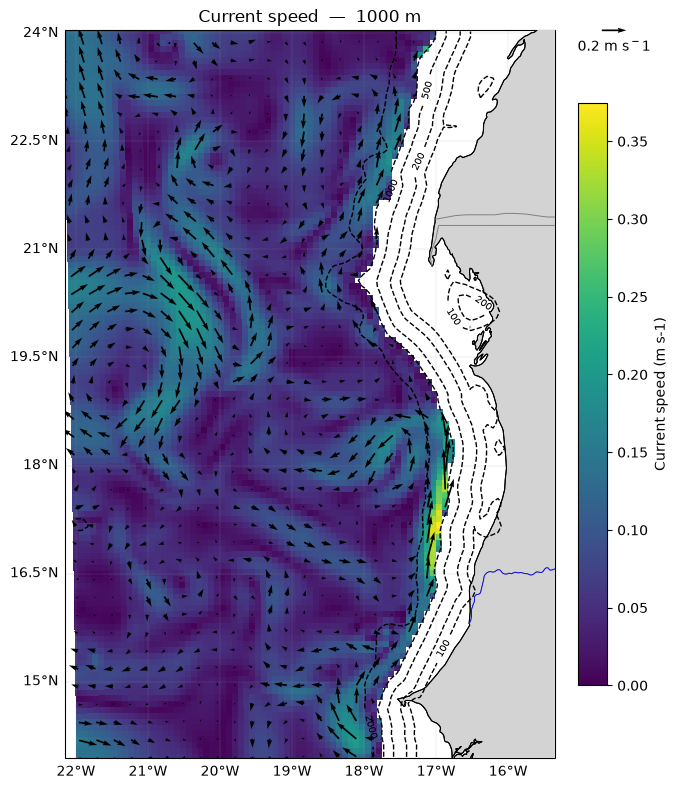

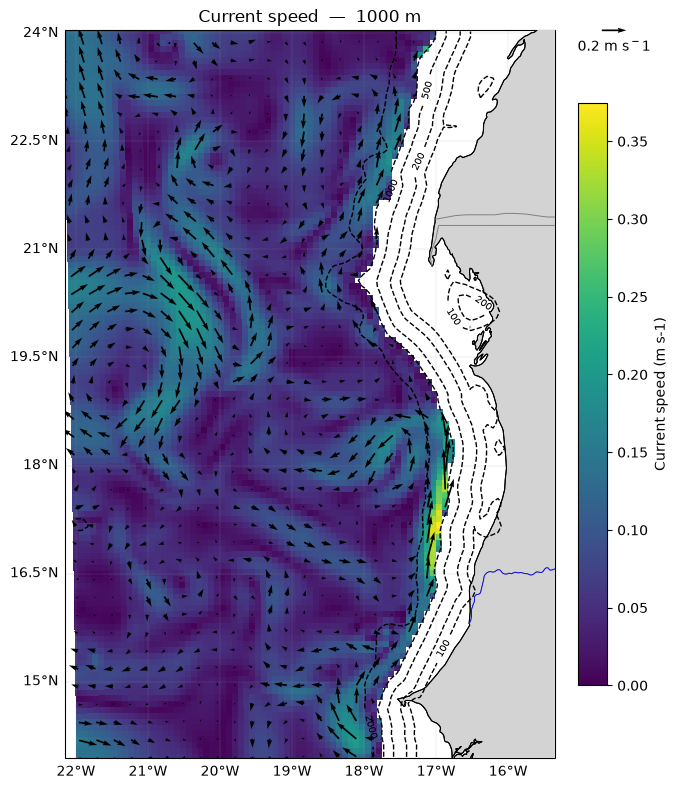

In [ ]:
# u, v = pp.surface_uv(ds,tindex=-1); # u,v at surface
# u, v = pp.rotate_uv(ds, u, v) #rotate to east/north for surface currents
u, v = u, v = pp.uv_at_depth(ds, depth_m=depth, tindex=-1, rotate=True)  # u,v at depth; 
fig=pl.plot(pp.speed_map(ds,depth_m=depth),ds=ds, uv=(u, v),isobaths=isobaths,uv_scale=4, uv_skip=3, uv_ref=0.2)   # saves to file, returns the filename

### Vorticity

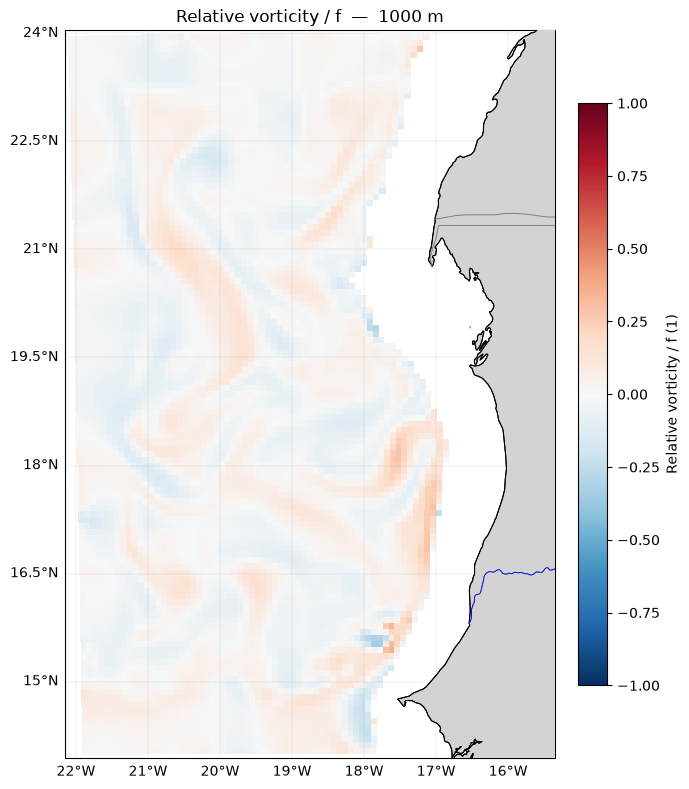

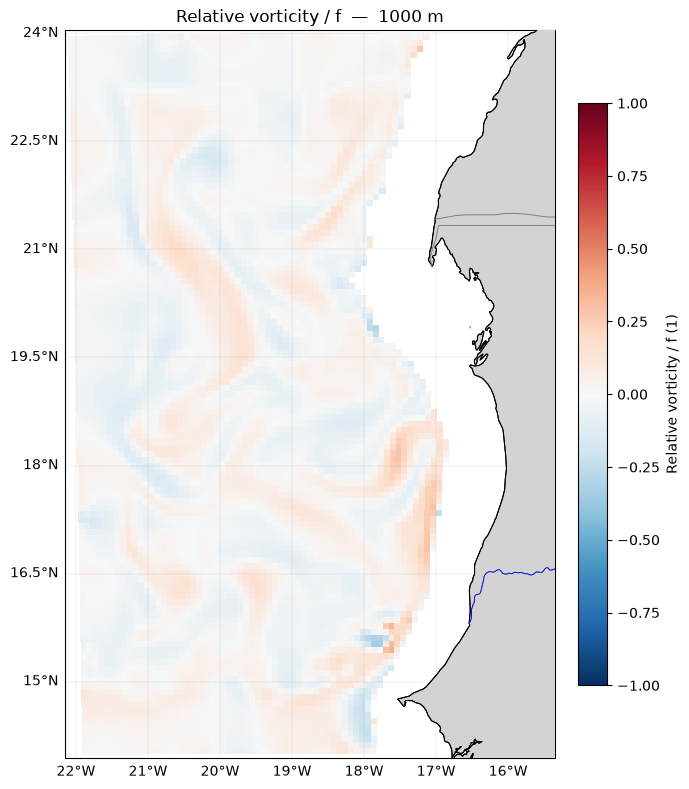

In [ ]:
fig=pl.plot(pp.vorticity(ds,depth_m=depth, normalized=True)) 

### Combined eddy view: shaded base field + vorticity contours or current vectors

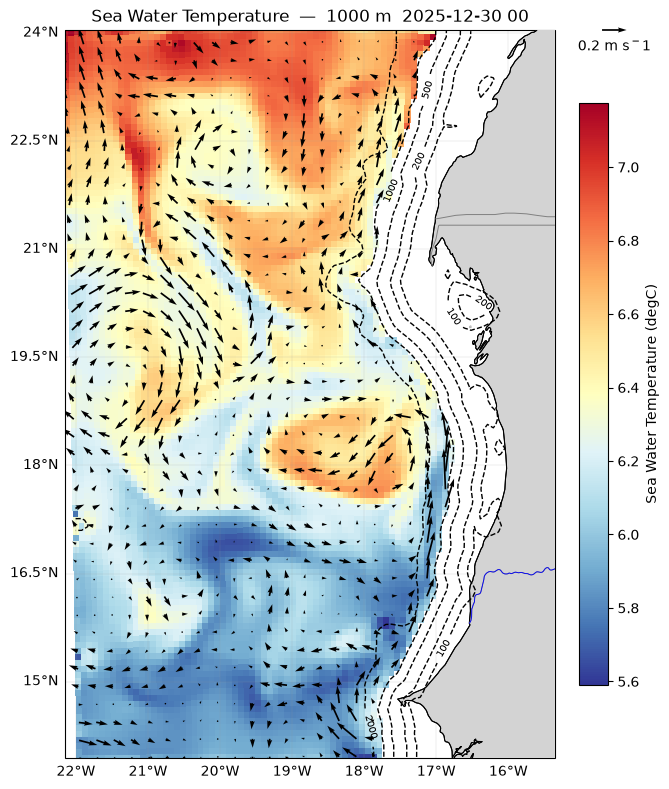

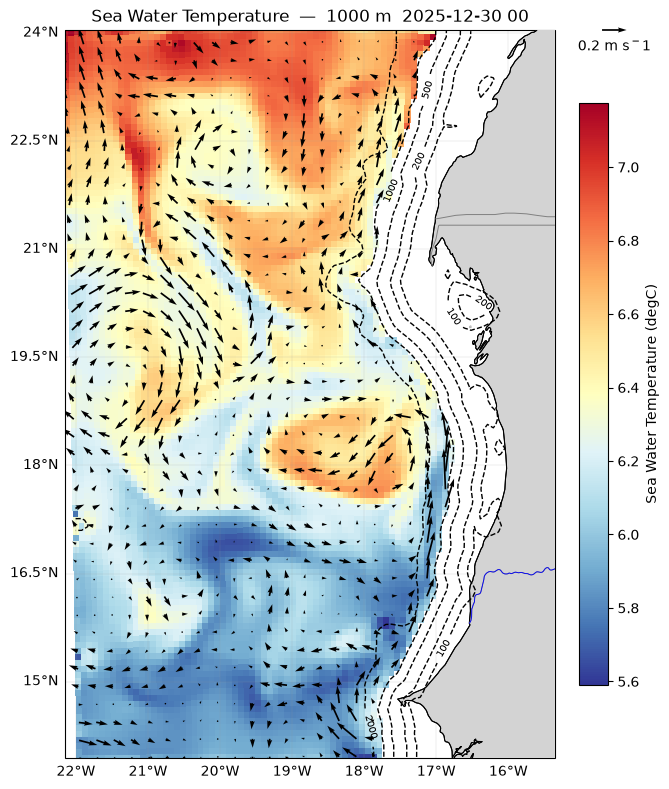

In [ ]:
# overlay : ('vort', vort_da)  -> vorticity contours (from vort/f)
#               ('uv', (u, v))     -> current vectors
fig = pl.plot_eddy(pp.field(ds, "temp", depth_m=depth),ds=ds, isobaths=isobaths,overlay= ('uv', (u, v)),uv_scale=4, uv_skip=3, uv_ref=0.2)   # no out= -> returns the figure

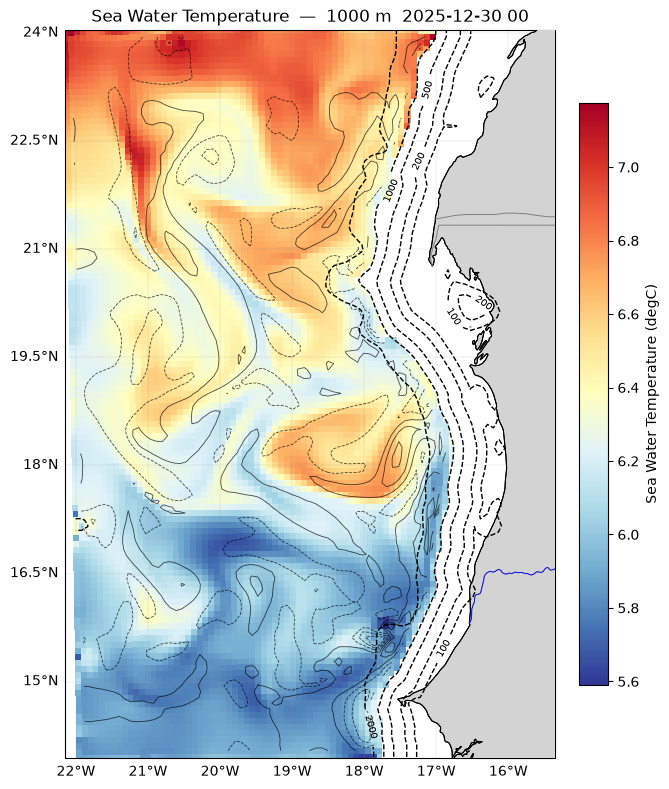

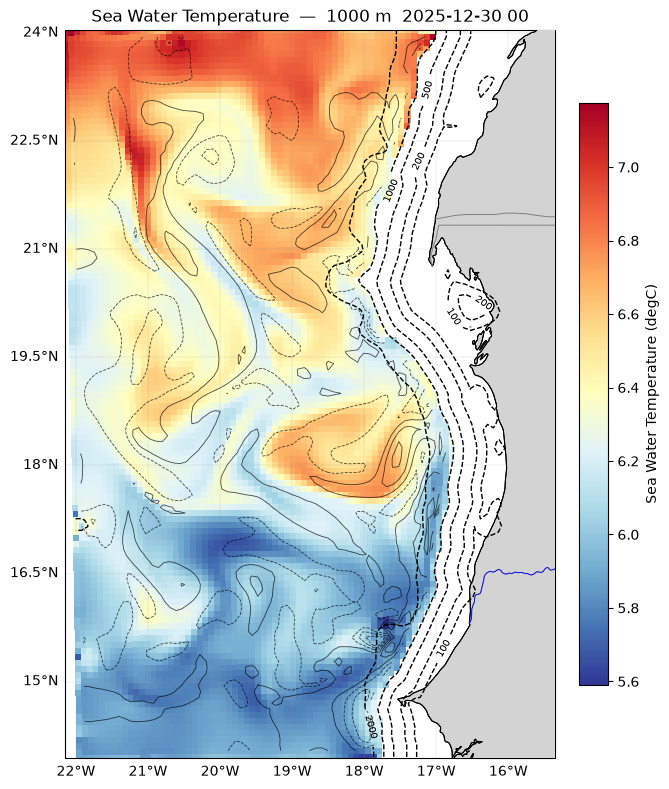

In [ ]:
# overlay : ('vort', vort_da)  -> vorticity contours (from vort/f)
#               ('uv', (u, v))     -> current vectors
vort_da = pp.vorticity(ds,depth_m=depth, normalized=True)
fig = pl.plot_eddy(pp.field(ds, "temp", depth_m=depth),ds=ds, isobaths=isobaths,overlay= ('vort', vort_da))   # no out= -> returns the figure

# ________________________________________________________________________________________________________________________________________

## Vertical section

### salinity

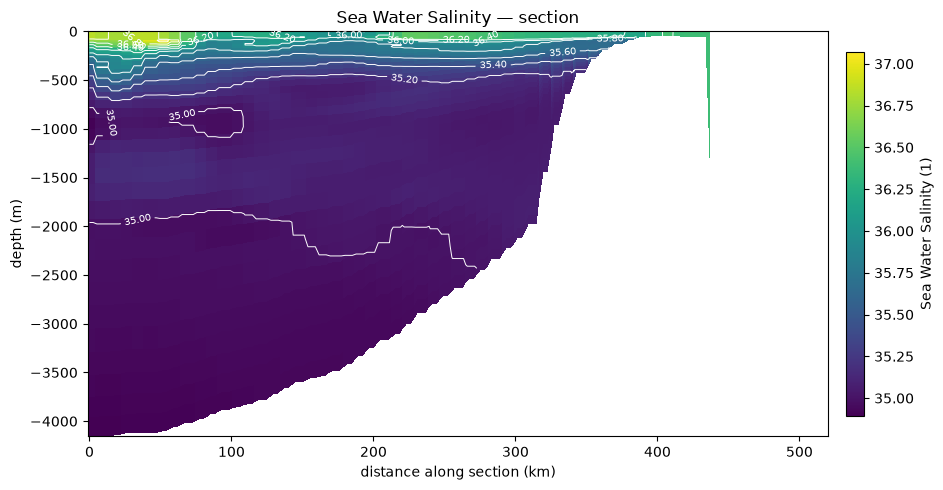

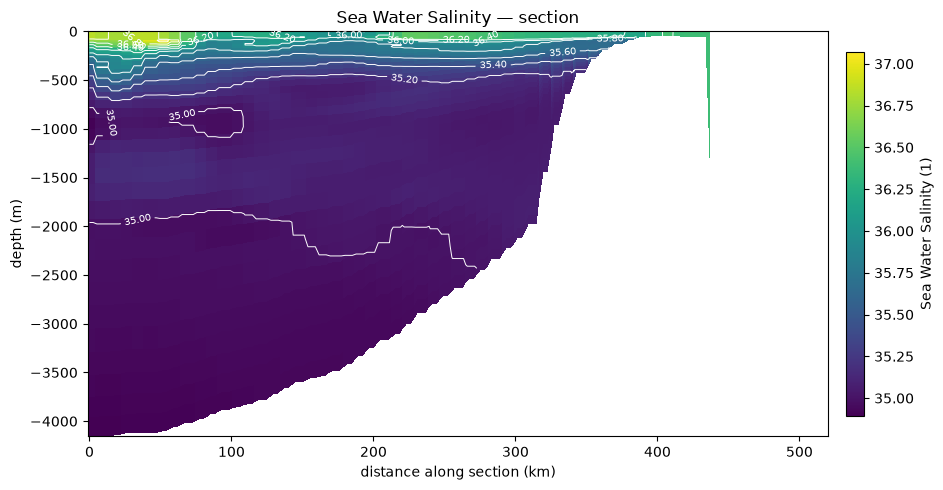

In [ ]:
fig=pl.plot(pp.section(ds, "salt",  lon0, lon1, lat0, lat1),contour_colors="white", levels=10)   # no out= -> returns the figure

### temperature

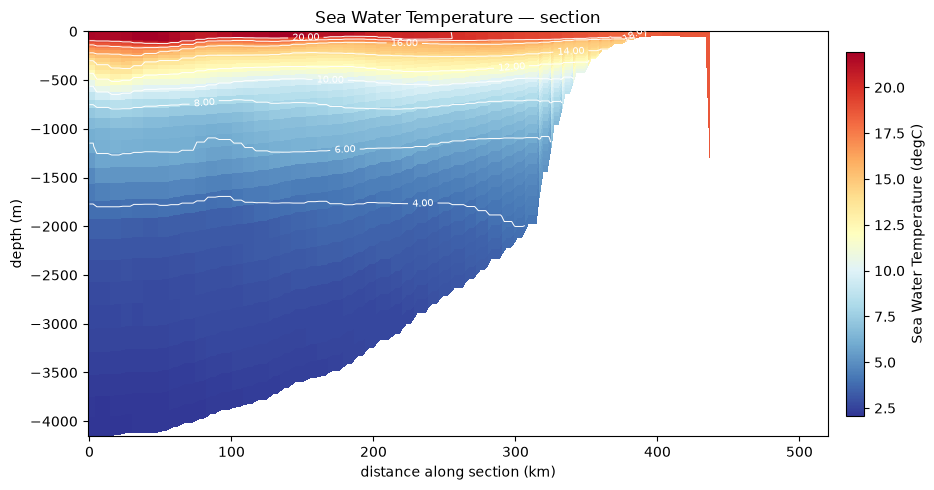

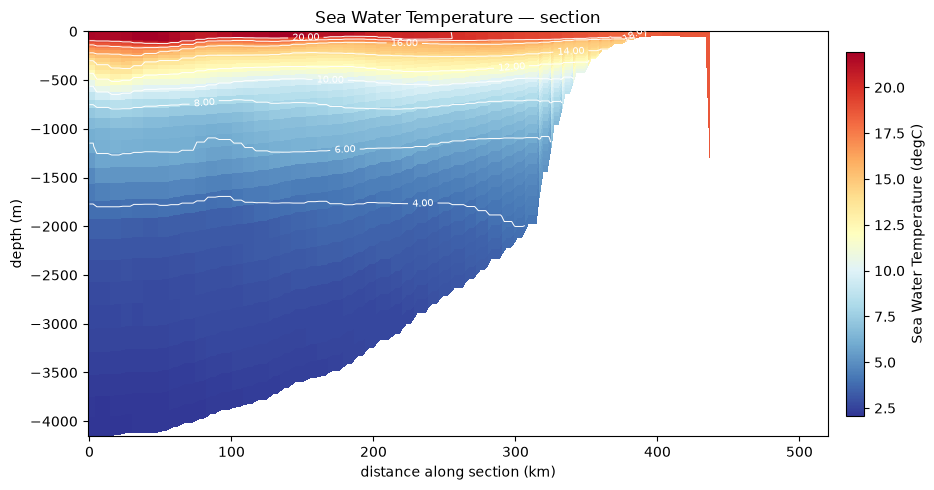

In [ ]:
fig=pl.plot(pp.section(ds, "temp",  lon0, lon1, lat0, lat1),contour_colors="white", levels=10)   # no out= -> returns the figure

### speed

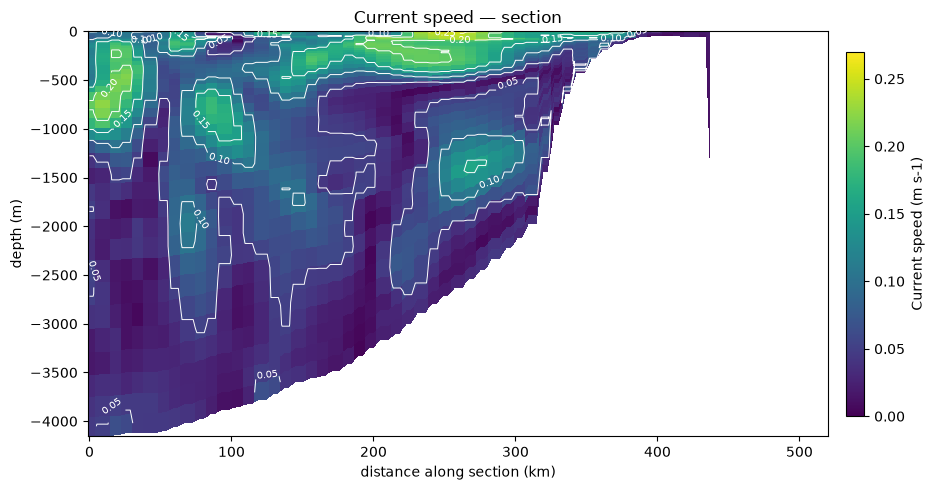

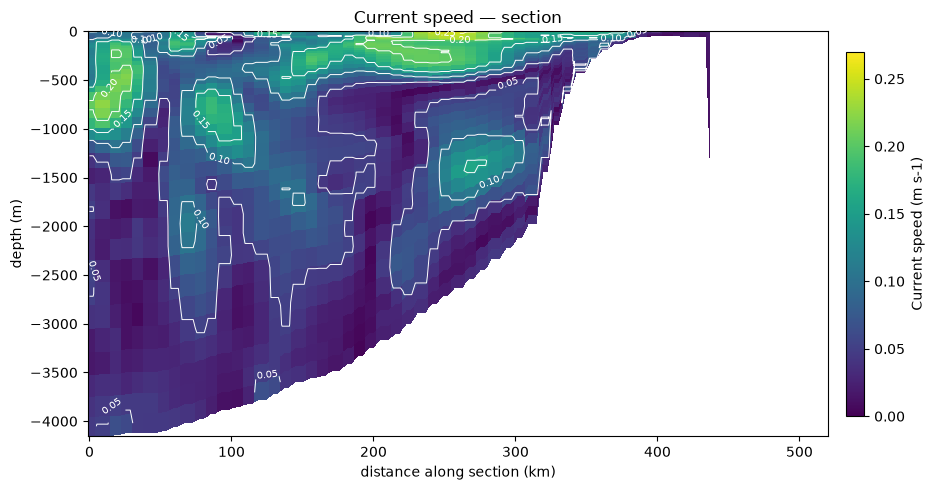

In [ ]:
fig=pl.plot(pp.section(ds, "speed",  lon0, lon1, lat0, lat1),contour_colors="white", levels=5)   # no out= -> returns the figure

### Zonal current (u)

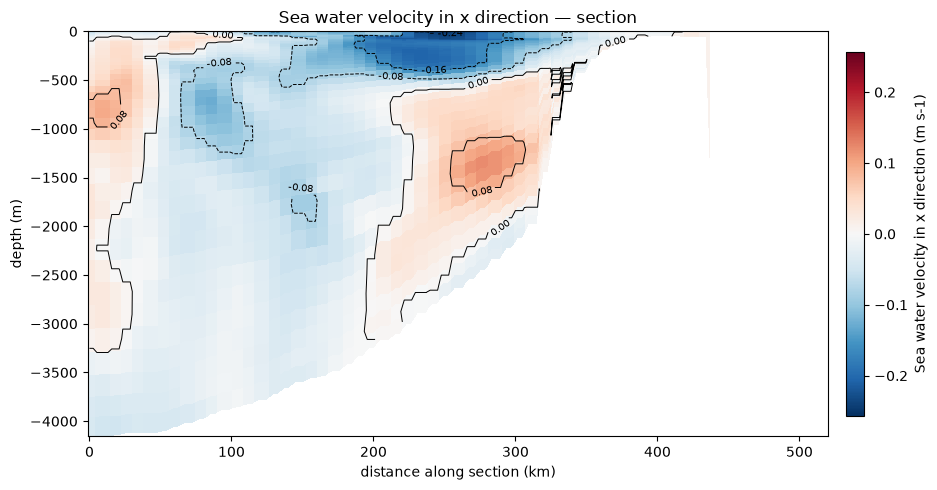

In [15]:
fig=pl.plot(pp.section(ds, "u",  lon0, lon1, lat0, lat1),contour_colors="black", levels=5)   # no out= -> returns the figure

### Meridional current (v)

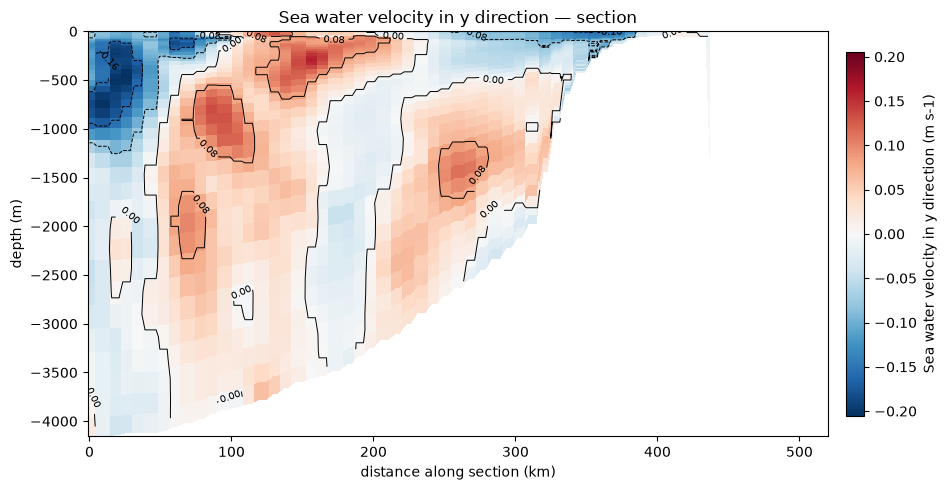

In [16]:
fig=pl.plot(pp.section(ds, "v",  lon0, lon1, lat0, lat1),contour_colors="black", levels=5)   # no out= -> returns the figure

# ________________________________________________________________________________________________________________________________________

## Vertcal Profil

###  salinity

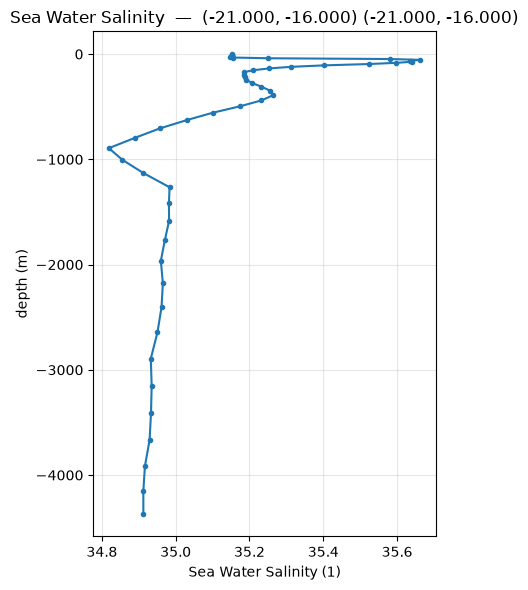

In [17]:
fig=pl.plot(pp.profile(ds, "salt",  lon0, lat0))

###  temperature

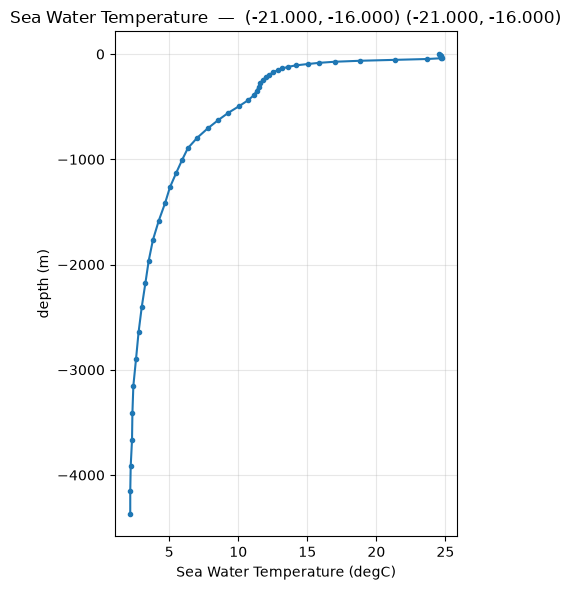

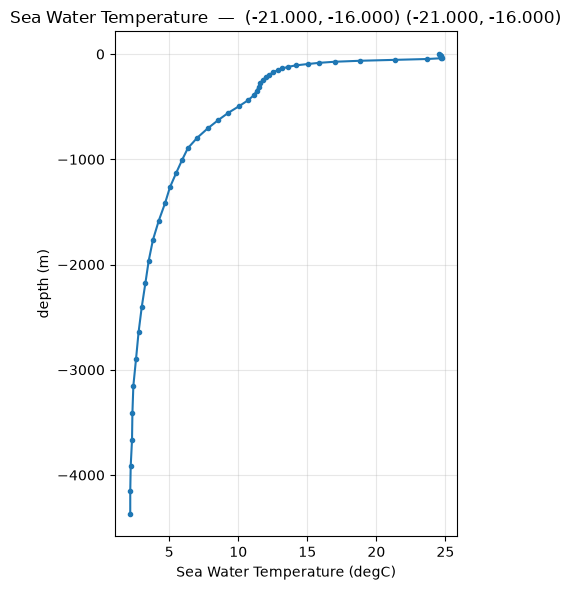

In [18]:
fig=pl.plot(pp.profile(ds, "temp",  lon0, lat0))
fig

###  speed

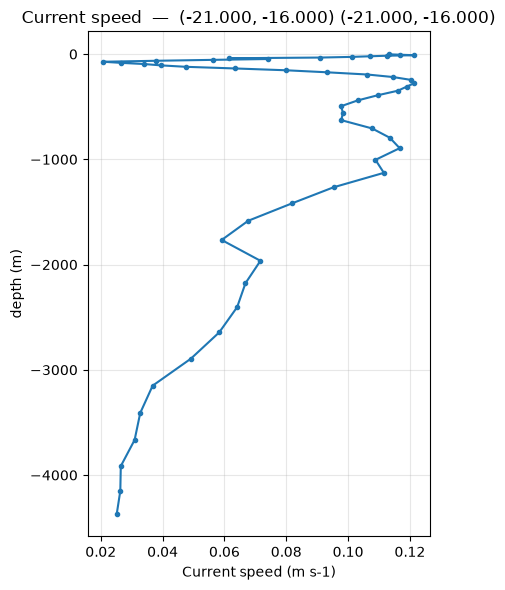

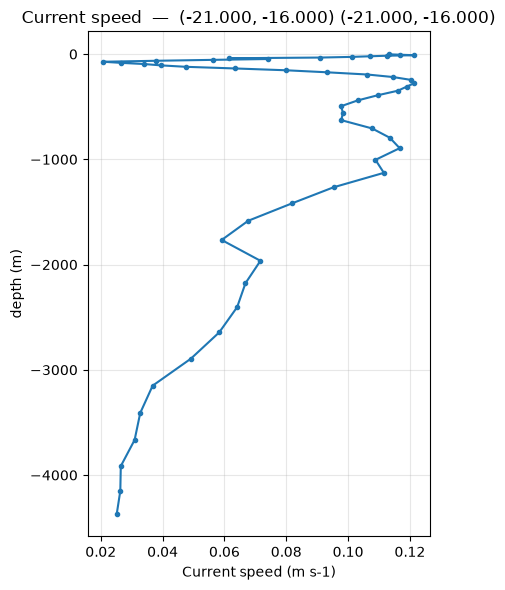

In [19]:
fig=pl.plot(pp.profile(ds, "speed",  lon0, lat0))
fig

### Zonal current (u)

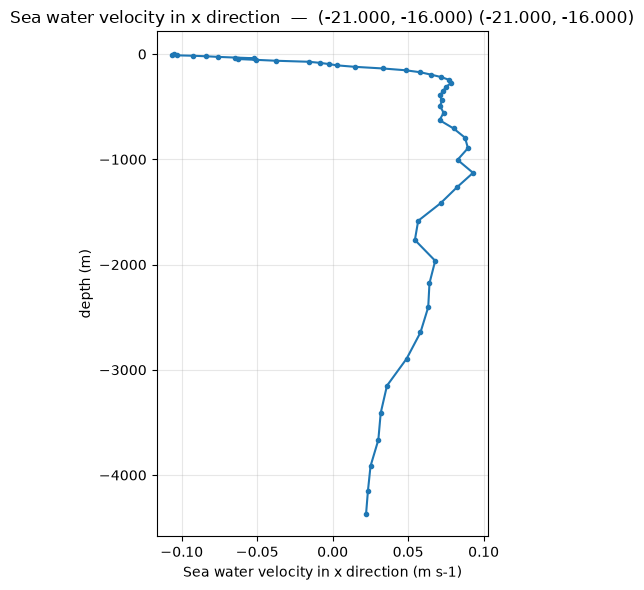

In [20]:
fig = pl.plot(pp.profile(ds, "u", lon0, lat0))

### Meridional current (v)

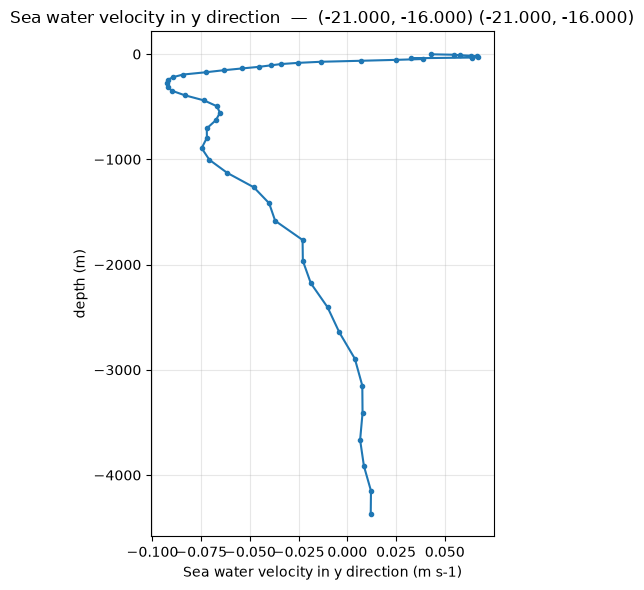

In [36]:
fig = pl.plot(pp.profile(ds, "v", lon0, lat0))

## Hovmöller diagrams

### salinity

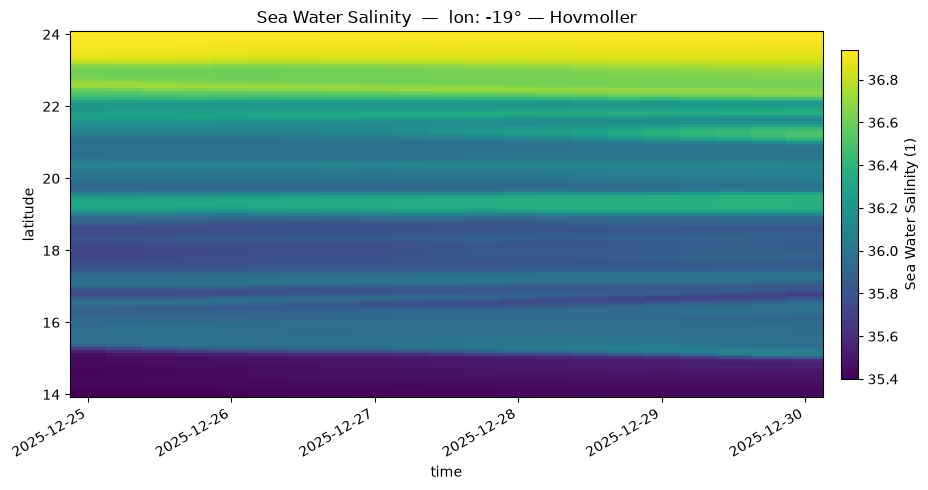

In [22]:
fig = pl.plot(pp.hovmoller(ds, "salt", "time_lat", lon0=-19))

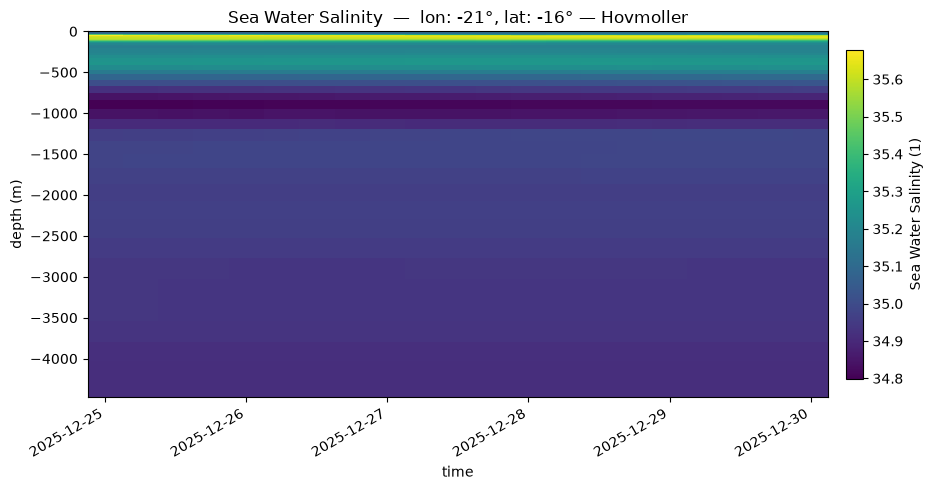

In [23]:
fig = pl.plot(pp.hovmoller(ds, "salt", kind="time_depth", lon0=lon0, lat0=lat0))


### temperature

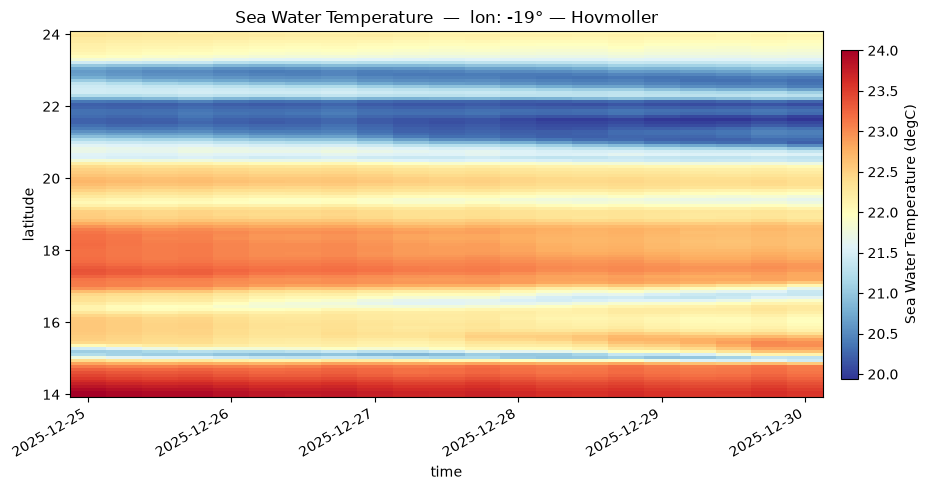

In [24]:
fig = pl.plot(pp.hovmoller(ds, "temp", "time_lat", lon0=-19))

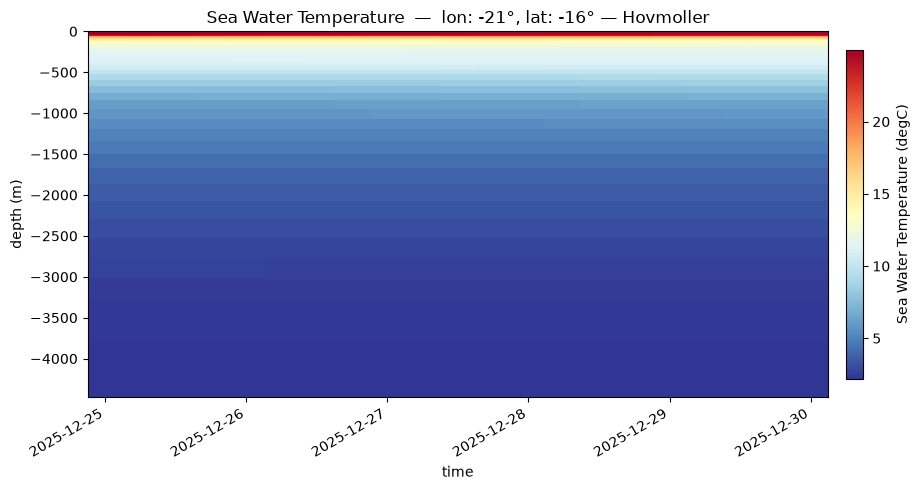

In [25]:
fig = pl.plot(pp.hovmoller(ds, "temp", kind="time_depth", lon0=lon0, lat0=lat0))


### Speed

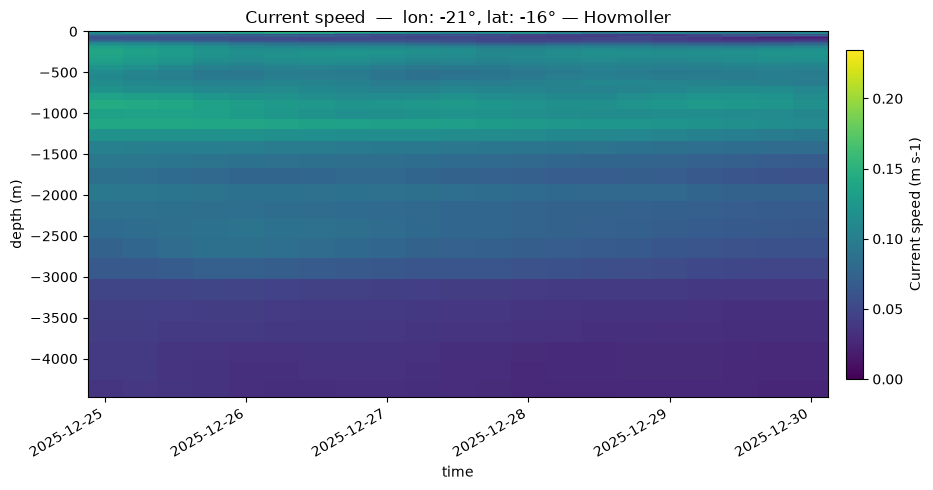

In [26]:
fig = pl.plot(pp.hovmoller(ds, "speed", kind="time_depth", lon0=lon0, lat0=lat0))


### Zonal current (u)

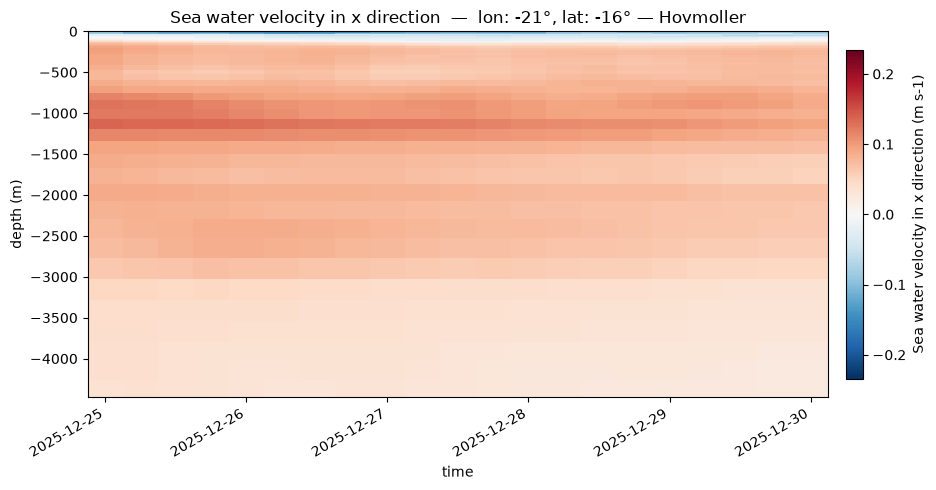

In [27]:
fig = pl.plot(pp.hovmoller(ds, "u", kind="time_depth", lon0=lon0, lat0=lat0))


### Meridional current (v)

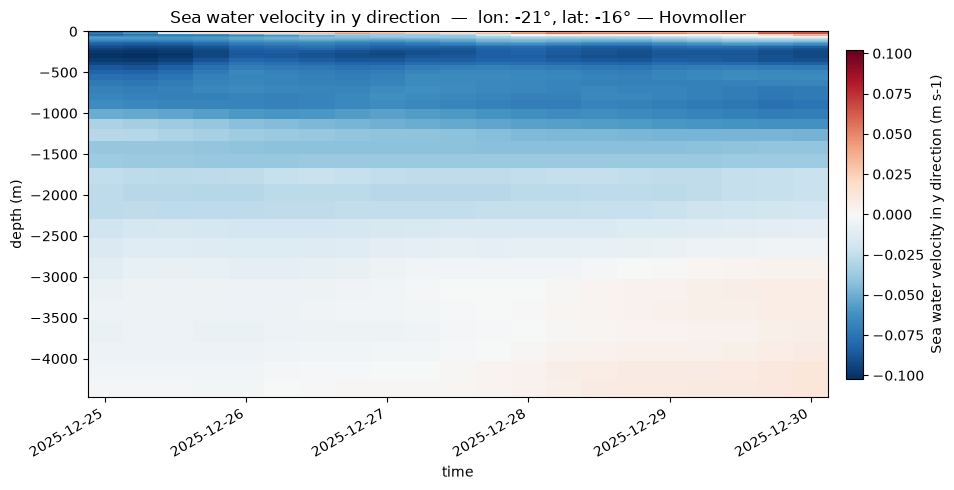

In [28]:
fig = pl.plot(pp.hovmoller(ds, "v", kind="time_depth", lon0=lon0, lat0=lat0))


## Time series

#### surface SST over time

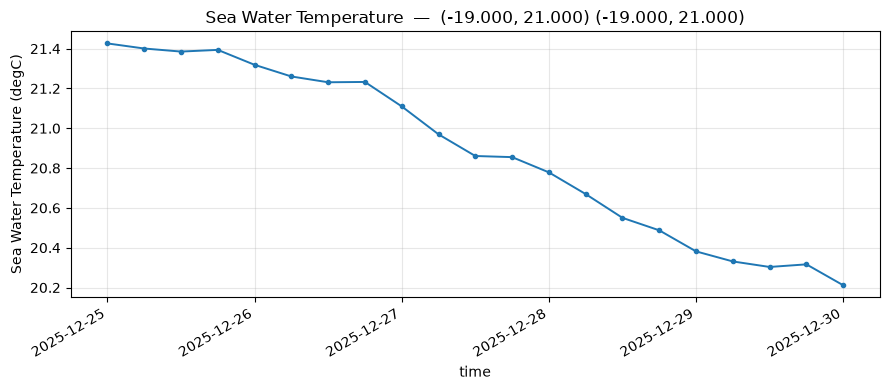

In [29]:
fig=pl.plot(pp.timeseries(ds, "temp",   lon0=-19, lat0=21))

### temperature at depth over time

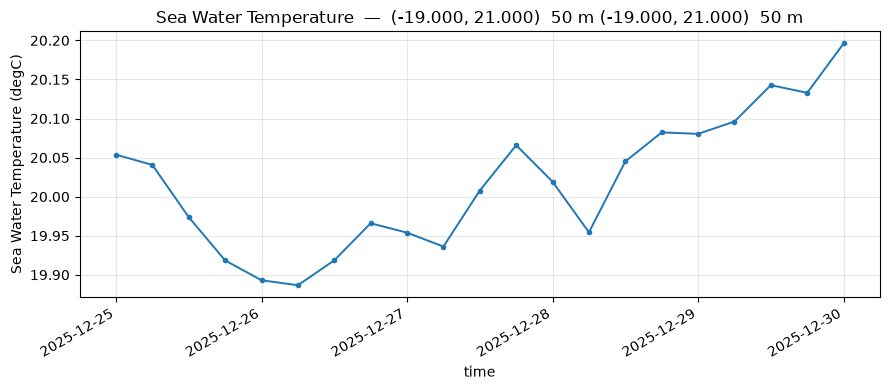

In [34]:
fig=pl.plot(pp.timeseries(ds, "temp", lon0=-19, lat0=21,depth_m=50))

### salinity at depth over time

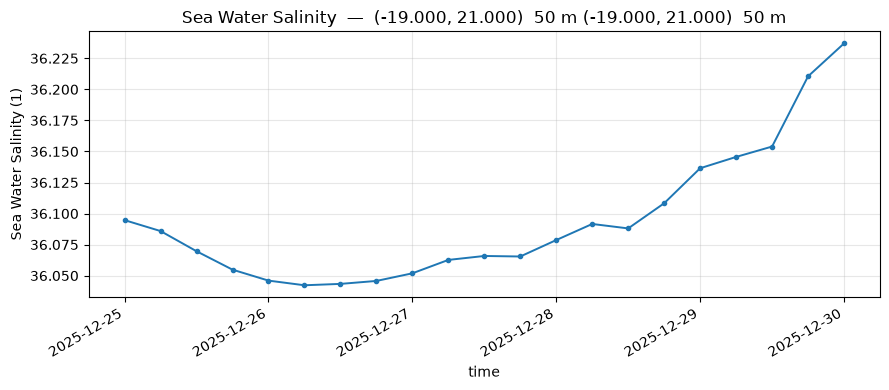

In [31]:
fig=pl.plot(pp.timeseries(ds, "salt", lon0=-19, lat0=21,depth_m=50))

#### SSH over time

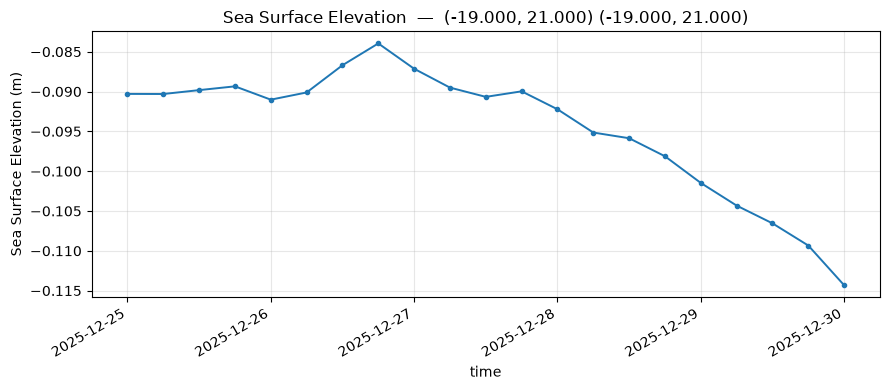

In [32]:
fig = pl.plot(pp.timeseries(ds, "zeta",  lon0=-19, lat0=21))

#### Speed at depth over time

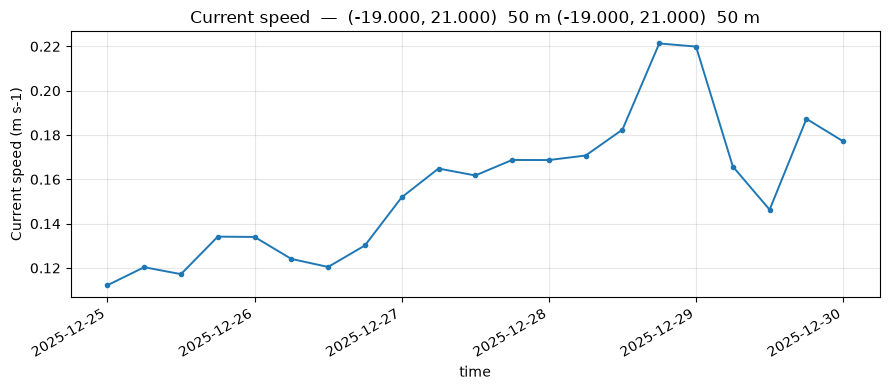

In [33]:
fig = pl.plot(pp.timeseries(ds, "speed",  lon0=-19, lat0=21, depth_m=50))
